# 08 — Evaluación en test (split por bloques, v2)

Copia de `05_evaluation.ipynb` apuntada a la corrida `v2_bloques`. Evalúa **solo** los
checkpoints de `data/06_models/v2_bloques/` contra el `manifest_test.csv` de la misma corrida:
los checkpoints de la v1 se entrenaron sobre otro reparto del territorio y mezclarlos aquí no
tendría sentido.

Respecto al notebook 05 hay una sección nueva, la **calibración del umbral de decisión**. En la
v1 la precisión de `com_garimpo` se quedó entre 0.54 y 0.67 con el umbral fijo en 0.5; ajustarlo
sobre validación permite elegir el punto de operación en lugar de heredarlo.

Salidas, todas bajo `v2_bloques/` y con sufijo propio:

```text
data/08_reporting/v2_bloques/test_results_summary_v2_bloques.csv
data/08_reporting/v2_bloques/test_results_v2_bloques.txt
data/08_reporting/v2_bloques/val_vs_test_comparison_v2_bloques.csv
data/08_reporting/v2_bloques/umbral_calibrado_v2_bloques.csv
reports/figures/{arquitectura}_v2_bloques_test_confusion.png
reports/figures/v2_bloques_precision_recall.png
```

## 1. Configuración

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, precision_recall_curve
from torch.utils.data import DataLoader

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import GarimpoDataset, get_transforms, load_manifest
from src.models.train import create_model
from src.utils.helpers import get_device, set_seed
from src.utils.metrics import compute_metrics

RUN_NAME = "v2_bloques"

DATA_DIR = ROOT / "data"
MANIFEST_DIR = DATA_DIR / "05_model_input" / RUN_NAME
MODELS_DIR = DATA_DIR / "06_models" / RUN_NAME
REPORT_DIR = DATA_DIR / "08_reporting" / RUN_NAME
FIGURES_DIR = ROOT / "reports" / "figures"

CHIPS_DIR_CANDIDATOS = [
    DATA_DIR / "01_raw" / "dataset_amazonia_garimpo_binario",
    DATA_DIR / "Dataset" / "datasets" / "amazonia_garimpo" / "dataset_amazonia_garimpo_binario",
]
CHIPS_DIR = next((p for p in CHIPS_DIR_CANDIDATOS if p.exists()), None)
if CHIPS_DIR is None:
    rutas = "\n  ".join(str(p) for p in CHIPS_DIR_CANDIDATOS)
    raise FileNotFoundError(f"No se encontró la carpeta de chips. Probadas:\n  {rutas}")

BATCH_SIZE = 32
NUM_WORKERS = 0
SEED = 42
LABELS = ["sem_garimpo", "com_garimpo"]
UMBRAL_BASE = 0.5
UMBRALES = np.round(np.arange(0.05, 0.96, 0.01), 2)

REPORT_DIR.mkdir(parents=True, exist_ok=True)

set_seed(SEED)
device = get_device()
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else str(device)

print(f"Corrida: {RUN_NAME}")
print(f"Device: {device}")
print(f"GPU: {gpu_name}")
print(f"PyTorch: {torch.__version__}")
print(f"Checkpoints : {MODELS_DIR}")
print(f"Manifiestos : {MANIFEST_DIR}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Corrida: v2_bloques
Device: cuda
GPU: NVIDIA GeForce RTX 5060
PyTorch: 2.12.0.dev20260408+cu128
Checkpoints : C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques
Manifiestos : C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\05_model_input\v2_bloques


## 2. DataLoaders de val y test

Test da el número final; val se usa únicamente para elegir el umbral, nunca para medir.
Igual que en el notebook 07, se construyen aquí para poder apuntar a la subcarpeta de la
corrida sin modificar `src/`.

In [2]:
def crear_loader(split: str) -> DataLoader:
    manifest = load_manifest(MANIFEST_DIR / f"manifest_{split}.csv")
    dataset = GarimpoDataset(
        manifest=manifest,
        chips_dir=CHIPS_DIR,
        transform=get_transforms(split),
    )
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )


val_loader = crear_loader("val")
test_loader = crear_loader("test")

for nombre, loader in (("val", val_loader), ("test", test_loader)):
    manifest = loader.dataset.manifest
    print(
        f"{nombre:<5} {len(manifest):>7,} chips | "
        f"{len(loader):>5,} batches | "
        f"com_garimpo {manifest['label_int'].mean() * 100:5.1f} %"
    )

val    16,518 chips |   517 batches | com_garimpo  51.1 %
test   17,312 chips |   541 batches | com_garimpo  50.2 %


## 3. Checkpoints de la corrida

Se buscan solo dentro de `data/06_models/v2_bloques/`, así que los `.pt` de la v1 quedan fuera
por construcción.

In [3]:
checkpoint_paths = sorted(MODELS_DIR.rglob("*_best.pt"))

print(f"Checkpoints encontrados en {MODELS_DIR}: {len(checkpoint_paths)}")
for p in checkpoint_paths:
    print(f"  - {p.name}")

if not checkpoint_paths:
    print(
        "\nNo hay checkpoints de esta corrida.\n"
        "Ejecuta antes 07_train_bloques.ipynb."
    )

Checkpoints encontrados en C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\v2_bloques: 4
  - efficientnet_b0_best.pt
  - resnet50_best.pt
  - swin_tiny_patch4_window7_224_best.pt
  - vit_tiny_patch16_224_best.pt


## 4. Helpers de evaluación

`inferir()` devuelve probabilidades en lugar de predicciones ya decididas, que es lo que hace
falta para poder mover el umbral después. Con umbral 0.5 el resultado es idéntico al `argmax`
que usa el notebook 05, así que las métricas principales siguen siendo comparables.

In [4]:
@torch.no_grad()
def inferir(ckpt_path: Path, loader: DataLoader, device) -> dict:
    """Carga un checkpoint y devuelve etiquetas reales y probabilidad de com_garimpo."""
    ckpt = torch.load(ckpt_path, map_location=device)
    model_name = ckpt["model_name"]
    img_size = ckpt.get("img_size", 128)

    model = create_model(model_name, img_size=img_size, pretrained=False).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    y_true, y_prob = [], []
    for images, labels in loader:
        images = images.to(device)
        probs = torch.softmax(model(images), dim=1)[:, 1]
        y_prob.extend(probs.cpu().tolist())
        y_true.extend(labels.tolist())

    return {
        "model_name": model_name,
        "train_best_epoch": ckpt.get("epoch"),
        "y_true": np.asarray(y_true),
        "y_prob": np.asarray(y_prob),
    }


def metricas_en_umbral(y_true: np.ndarray, y_prob: np.ndarray, umbral: float) -> dict:
    return compute_metrics(y_true, (y_prob >= umbral).astype(int))


def plot_confusion_matrix(y_true, y_pred, title: str, save_path: Path) -> None:
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=LABELS, yticklabels=LABELS, ax=ax,
    )
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_title(title)
    plt.tight_layout()
    save_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

## 5. Evaluar cada checkpoint en test


[1/4] Evaluando: efficientnet_b0_best.pt
accuracy 0.7744 | macro F1 0.7744 | recall com_garimpo 0.7589 | precision com_garimpo 0.7846


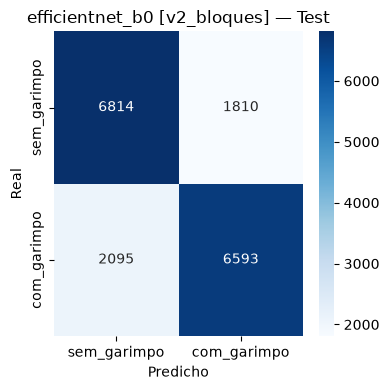


[2/4] Evaluando: resnet50_best.pt
accuracy 0.7477 | macro F1 0.7465 | recall com_garimpo 0.6763 | precision com_garimpo 0.7906


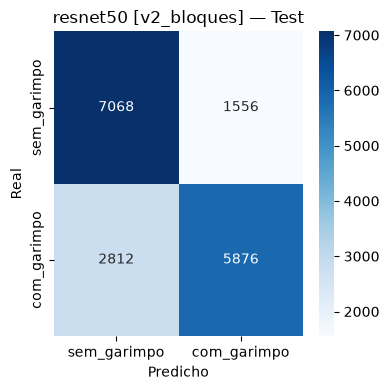


[3/4] Evaluando: swin_tiny_patch4_window7_224_best.pt
accuracy 0.7897 | macro F1 0.7897 | recall com_garimpo 0.7972 | precision com_garimpo 0.7866


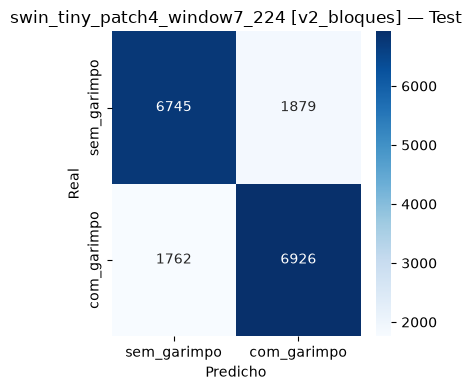


[4/4] Evaluando: vit_tiny_patch16_224_best.pt
accuracy 0.7371 | macro F1 0.7363 | recall com_garimpo 0.6783 | precision com_garimpo 0.7704


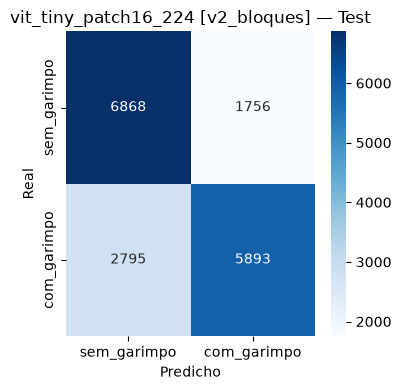


Evaluación completada.


In [5]:
results = []
inferencias = {}
log_lines = [
    f"EVALUACIÓN EN TEST ({RUN_NAME}) — RESULTADOS",
    f"Fecha: {datetime.now().strftime('%Y-%m-%d %H:%M')}",
    f"Device: {device} | GPU: {gpu_name}",
    f"Manifiestos: {MANIFEST_DIR}",
    f"Test chips: {len(test_loader.dataset):,} "
    f"(com_garimpo {test_loader.dataset.manifest['label_int'].mean() * 100:.1f} %)",
    f"Umbral de decisión: {UMBRAL_BASE}",
    "",
]

for i, ckpt_path in enumerate(checkpoint_paths, start=1):
    print("\n" + "=" * 60)
    print(f"[{i}/{len(checkpoint_paths)}] Evaluando: {ckpt_path.name}")
    print("=" * 60)

    inf = inferir(ckpt_path, test_loader, device)
    inferencias[ckpt_path] = inf

    m = metricas_en_umbral(inf["y_true"], inf["y_prob"], UMBRAL_BASE)
    label = f"{inf['model_name']} [{RUN_NAME}]"

    print(
        f"accuracy {m['accuracy']:.4f} | macro F1 {m['macro_f1']:.4f} | "
        f"recall com_garimpo {m['recall_com_garimpo']:.4f} | "
        f"precision com_garimpo {m['precision_com_garimpo']:.4f}"
    )

    plot_confusion_matrix(
        inf["y_true"],
        (inf["y_prob"] >= UMBRAL_BASE).astype(int),
        title=f"{label} — Test",
        save_path=FIGURES_DIR / f"{inf['model_name']}_{RUN_NAME}_test_confusion.png",
    )

    log_lines += [
        f"MODELO: {label} ({ckpt_path.name})",
        f"  test accuracy: {m['accuracy']:.4f}",
        f"  test macro F1: {m['macro_f1']:.4f}",
        f"  f1 com_garimpo: {m['f1_com_garimpo']:.4f} | f1 sem_garimpo: {m['f1_sem_garimpo']:.4f}",
        f"  recall com_garimpo: {m['recall_com_garimpo']:.4f} | precision com_garimpo: {m['precision_com_garimpo']:.4f}",
        "",
    ]

    results.append({
        "model": inf["model_name"],
        "variant": RUN_NAME,
        "checkpoint": ckpt_path.name,
        "train_best_epoch": inf["train_best_epoch"],
        "test_accuracy": round(m["accuracy"], 4),
        "test_macro_f1": round(m["macro_f1"], 4),
        "test_f1_com_garimpo": round(m["f1_com_garimpo"], 4),
        "test_f1_sem_garimpo": round(m["f1_sem_garimpo"], 4),
        "test_recall_com_garimpo": round(m["recall_com_garimpo"], 4),
        "test_precision_com_garimpo": round(m["precision_com_garimpo"], 4),
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("\nEvaluación completada.")

## 6. Resumen comparativo en test

In [6]:
results_df = pd.DataFrame(results).sort_values("test_macro_f1", ascending=False)
display(results_df)

summary_csv = REPORT_DIR / f"test_results_summary_{RUN_NAME}.csv"
results_df.to_csv(summary_csv, index=False)

best = results_df.iloc[0]
log_lines += [
    "=" * 60,
    f"RESUMEN COMPARATIVO (test, {RUN_NAME})",
    "=" * 60,
    "",
    results_df.to_string(index=False),
    "",
    f"MEJOR MODELO EN TEST: {best['model']} | "
    f"test macro F1 = {best['test_macro_f1']} | accuracy = {best['test_accuracy']}",
    f"Checkpoint: {best['checkpoint']}",
]

summary_txt = REPORT_DIR / f"test_results_{RUN_NAME}.txt"
summary_txt.write_text("\n".join(log_lines), encoding="utf-8")

print("\nArchivos guardados:")
print(f"  {summary_csv}")
print(f"  {summary_txt}")
print(f"\nMejor modelo en TEST: {best['model']}")
print(f"  Accuracy: {best['test_accuracy'] * 100:.1f} %")
print(f"  Macro F1: {best['test_macro_f1'] * 100:.1f} %")

,model,variant,checkpoint,train_best_epoch,test_accuracy,test_macro_f1,test_f1_com_garimpo,test_f1_sem_garimpo,test_recall_com_garimpo,test_precision_com_garimpo
2,swin_tiny_patch4_window7_224,v2_bloques,swin_tiny_patch4_window7_224_best.pt,4,0.7897,0.7897,0.7919,0.7875,0.7972,0.7866
0,efficientnet_b0,v2_bloques,efficientnet_b0_best.pt,4,0.7744,0.7744,0.7715,0.7773,0.7589,0.7846
1,resnet50,v2_bloques,resnet50_best.pt,6,0.7477,0.7465,0.7290,0.7639,0.6763,0.7906
3,vit_tiny_patch16_224,v2_bloques,vit_tiny_patch16_224_best.pt,2,0.7371,0.7363,0.7214,0.7511,0.6783,0.7704



Archivos guardados:
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques\test_results_summary_v2_bloques.csv
  C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques\test_results_v2_bloques.txt

Mejor modelo en TEST: swin_tiny_patch4_window7_224
  Accuracy: 79.0 %
  Macro F1: 79.0 %


## 7. Val vs. test

Con el split por bloques, val y test tienen prácticamente la misma prevalencia de garimpo, así
que la caída de macro F1 entre uno y otro ya sí mide sobreajuste y no un cambio de dificultad.
En la v1 esta comparación no era interpretable: test subía respecto a val simplemente porque
tenía un 19 % de positivos frente al 45 % de val.

In [7]:
val_summary_csv = REPORT_DIR / f"training_results_summary_{RUN_NAME}.csv"

if val_summary_csv.exists():
    val_df = pd.read_csv(val_summary_csv)[["timm_name", "val_macro_f1", "val_accuracy"]]
    comparison = results_df.merge(
        val_df, left_on="model", right_on="timm_name", how="left"
    ).drop(columns=["timm_name"])
    comparison["f1_drop_val_to_test"] = (
        comparison["val_macro_f1"] - comparison["test_macro_f1"]
    ).round(4)

    cols = [
        "model", "val_macro_f1", "test_macro_f1", "f1_drop_val_to_test",
        "val_accuracy", "test_accuracy",
    ]
    display(comparison[cols].sort_values("f1_drop_val_to_test"))

    comparison_csv = REPORT_DIR / f"val_vs_test_comparison_{RUN_NAME}.csv"
    comparison[cols].to_csv(comparison_csv, index=False)
    print(f"\nGuardado: {comparison_csv}")
else:
    print(f"No se encontró {val_summary_csv} (corrida de 07_train_bloques.ipynb).")

,model,val_macro_f1,test_macro_f1,f1_drop_val_to_test,val_accuracy,test_accuracy
0,swin_tiny_patch4_window7_224,0.8093,0.7897,0.0196,0.8097,0.7897
1,efficientnet_b0,0.8090,0.7744,0.0346,0.8091,0.7744
2,resnet50,0.8074,0.7465,0.0609,0.8077,0.7477
3,vit_tiny_patch16_224,0.8059,0.7363,0.0696,0.8059,0.7371



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques\val_vs_test_comparison_v2_bloques.csv


## 8. Calibración del umbral de decisión

El umbral 0.5 no tiene nada de especial: es lo que sale por defecto de un `argmax`. Aquí se
barre el umbral **sobre validación**, se elige el que maximiza el macro F1, y ese umbral se
aplica a test. Como la elección se hace en val, la métrica de test sigue siendo honesta.

Esto ataca directamente el punto débil de la v1: la precisión de `com_garimpo`. Subir el umbral
reduce falsas alarmas a costa de recall; bajarlo hace lo contrario. La tabla deja ver el
intercambio con números en lugar de en abstracto.

In [8]:
filas_umbral = []

for ckpt_path in checkpoint_paths:
    inf_test = inferencias[ckpt_path]
    inf_val = inferir(ckpt_path, val_loader, device)
    nombre = inf_test["model_name"]

    barrido = [
        (u, metricas_en_umbral(inf_val["y_true"], inf_val["y_prob"], u)["macro_f1"])
        for u in UMBRALES
    ]
    umbral_opt = max(barrido, key=lambda par: par[1])[0]

    base = metricas_en_umbral(inf_test["y_true"], inf_test["y_prob"], UMBRAL_BASE)
    calibrado = metricas_en_umbral(inf_test["y_true"], inf_test["y_prob"], umbral_opt)

    filas_umbral.append({
        "model": nombre,
        "umbral_optimo_val": umbral_opt,
        "test_macro_f1_05": round(base["macro_f1"], 4),
        "test_macro_f1_calibrado": round(calibrado["macro_f1"], 4),
        "ganancia_f1": round(calibrado["macro_f1"] - base["macro_f1"], 4),
        "precision_com_05": round(base["precision_com_garimpo"], 4),
        "precision_com_calibrado": round(calibrado["precision_com_garimpo"], 4),
        "recall_com_05": round(base["recall_com_garimpo"], 4),
        "recall_com_calibrado": round(calibrado["recall_com_garimpo"], 4),
    })

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

umbral_df = pd.DataFrame(filas_umbral).sort_values("test_macro_f1_calibrado", ascending=False)
umbral_df.to_csv(REPORT_DIR / f"umbral_calibrado_{RUN_NAME}.csv", index=False)
display(umbral_df)

print(f"\nGuardado: {REPORT_DIR / f'umbral_calibrado_{RUN_NAME}.csv'}")

,model,umbral_optimo_val,test_macro_f1_05,test_macro_f1_calibrado,ganancia_f1,precision_com_05,precision_com_calibrado,recall_com_05,recall_com_calibrado
2,swin_tiny_patch4_window7_224,0.54,0.7897,0.7895,-0.0002,0.7866,0.8098,0.7972,0.7591
0,efficientnet_b0,0.55,0.7744,0.7621,-0.0123,0.7846,0.8029,0.7589,0.6992
1,resnet50,0.44,0.7465,0.7570,0.0105,0.7906,0.7645,0.6763,0.7454
3,vit_tiny_patch16_224,0.48,0.7363,0.7389,0.0026,0.7704,0.7565,0.6783,0.7082



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques\umbral_calibrado_v2_bloques.csv


### Curvas precisión–recall en test

Cada curva muestra todos los puntos de operación posibles de un modelo. Es la figura que permite
justificar el umbral elegido según el uso: detección exhaustiva (recall alto) o mapa operativo
con pocas falsas alarmas (precisión alta).

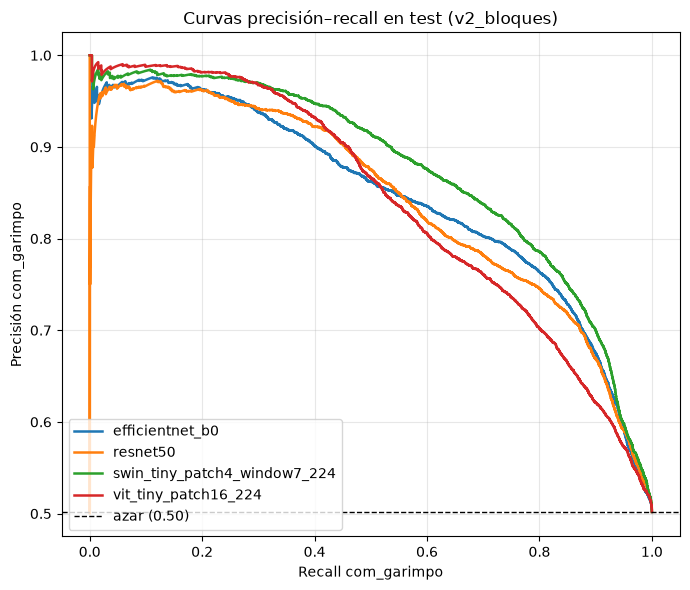

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

for ckpt_path in checkpoint_paths:
    inf = inferencias[ckpt_path]
    precision, recall, _ = precision_recall_curve(inf["y_true"], inf["y_prob"])
    ax.plot(recall, precision, lw=1.8, label=inf["model_name"])

prevalencia = test_loader.dataset.manifest["label_int"].mean()
ax.axhline(prevalencia, color="black", ls="--", lw=1, label=f"azar ({prevalencia:.2f})")

ax.set_xlabel("Recall com_garimpo")
ax.set_ylabel("Precisión com_garimpo")
ax.set_title(f"Curvas precisión–recall en test ({RUN_NAME})")
ax.legend(loc="lower left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / f"{RUN_NAME}_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Referencia: resultados de la v1

**Los dos conjuntos de test son distintos**, así que estas cifras no se pueden comparar
directamente: el test de la v1 tenía un 19 % de positivos y el de la v2 ronda el 50 %, lo que
hace que la accuracy de la v1 se vea inflada por la clase mayoritaria. La tabla sirve para
documentar ambas corridas en el informe, no para declarar un ganador entre ellas.

In [10]:
v1_csv = DATA_DIR / "08_reporting" / "test_results_summary.csv"

if v1_csv.exists():
    v1_df = pd.read_csv(v1_csv)
    v1_mejor = (
        v1_df.sort_values("test_macro_f1", ascending=False)
        .groupby("model", as_index=False)
        .first()[["model", "variant", "test_macro_f1", "test_precision_com_garimpo", "test_recall_com_garimpo"]]
        .rename(columns={
            "variant": "mejor_variante_v1",
            "test_macro_f1": "test_macro_f1_v1",
            "test_precision_com_garimpo": "precision_com_v1",
            "test_recall_com_garimpo": "recall_com_v1",
        })
    )

    v2_resumen = results_df[[
        "model", "test_macro_f1", "test_precision_com_garimpo", "test_recall_com_garimpo",
    ]].rename(columns={
        "test_macro_f1": "test_macro_f1_v2",
        "test_precision_com_garimpo": "precision_com_v2",
        "test_recall_com_garimpo": "recall_com_v2",
    })

    referencia = v1_mejor.merge(v2_resumen, on="model", how="outer")
    display(referencia)

    ruta = REPORT_DIR / f"referencia_v1_vs_{RUN_NAME}_test.csv"
    referencia.to_csv(ruta, index=False)
    print(f"\nGuardado: {ruta}")
    print("\nRecordatorio: test sets distintos, las cifras no son directamente comparables.")
else:
    print(f"No se encontró {v1_csv}.")

,model,mejor_variante_v1,test_macro_f1_v1,precision_com_v1,recall_com_v1,test_macro_f1_v2,precision_com_v2,recall_com_v2
0,efficientnet_b0,scratch,0.8037,0.6354,0.7536,0.7744,0.7846,0.7589
1,resnet50,scratch,0.8076,0.6682,0.7166,0.7465,0.7906,0.6763
2,swin_tiny_patch4_window7_224,tuned,0.7879,0.5723,0.8214,0.7897,0.7866,0.7972
3,vit_tiny_patch16_224,tuned,0.8080,0.6416,0.7614,0.7363,0.7704,0.6783



Guardado: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\08_reporting\v2_bloques\referencia_v1_vs_v2_bloques_test.csv

Recordatorio: test sets distintos, las cifras no son directamente comparables.


## 10. Qué llevarse al informe

De esta corrida salen las tres piezas que faltaban:

- **Comparación limpia de 4 arquitecturas** bajo un protocolo único y con val y test
  equilibrados, así que el modelo elegido en validación es el que debería ganar en test.
- **Punto de operación justificado**, con el umbral elegido en val y las curvas precisión–recall
  para defender la decisión.
- **Ablaciones de la v1** (preentrenado vs. scratch, LR original vs. ajustado, split por ráster
  vs. por bloques) que siguen intactas en `data/08_reporting/`.